# BamiBERT Baseline Model for Vietnamese Fact-Checking
## Mô hình NLI Tiền huấn luyện cho Bài toán Kiểm chứng Thông tin Tiếng Việt (ViFactCheck)

---

### 1. Giới thiệu Bài toán Fact-Checking dưới góc nhìn NLI
Trong hệ thống Fact-Checking tự động, sau giai đoạn trích xuất bằng chứng (Evidence Retrieval), mô hình NLI đóng vai trò bộ phân loại suy luận logic (Natural Language Inference) cho từng cặp câu:
- **Tuyên bố (Statement / Claim):** Nhận định cần được xác thực tính đúng sai.
- **Bằng chứng (Evidence):** Đoạn văn hoặc câu đối chứng được trích xuất từ nguồn báo chí / tri thức đáng tin cậy.

Nhiệm vụ phân loại mối quan hệ ngữ nghĩa thành **3 nhãn logic**:
- **`0: SUPPORTED`** — Bằng chứng ủng hộ / xác nhận tuyên bố là đúng sự thật.
- **`1: REFUTED`** — Bằng chứng bác bỏ / mâu thuẫn trực tiếp với tuyên bố (về thời gian, nhân vật, số liệu hoặc sự kiện).
- **`2: NEI (Not Enough Information)`** — Bằng chứng không cung cấp đủ dữ kiện để khẳng định hay phủ định.

---

### 2. Vì sao BamiBERT thích hợp cho Bài toán Fact-Checking?
BamiBERT (`Qualcomm-AI-Research/BamiBERT`) là mô hình ngôn ngữ BERT-based được tiền huấn luyện sâu từ đầu trên 129 GB ngữ liệu tiếng Việt tổng quát với nhiều đặc tính ưu việt rất phù hợp cho bài toán kiểm chứng thông tin:

1. **Xử lý trực tiếp văn bản thô (Raw text input):**
   - Mô hình sử dụng bộ tokenizer byte-level BPE tiếng Việt (mở rộng từ PhoGPT kèm token `<mask}`, kích thước từ vựng tối ưu 20,481 token types).
   - Tiếp nhận trực tiếp văn bản tự nhiên mà không phụ thuộc vào công cụ tách từ bên ngoài, giúp tinh gọn pipeline xử lý và **triệt tiêu hoàn toàn nguy cơ lan truyền sai số tách từ (*word segmentation error propagation*)**.
2. **Khả năng xử lý ngữ cảnh dài (Long Context up to 2,048 tokens):**
   - BamiBERT hỗ trợ độ dài ngữ cảnh mở rộng lên đến 2,048 tokens.
   - Nhờ đó, mô hình tiếp nhận trọn vẹn cả những cặp Tuyên bố và Bằng chứng dài hoặc các bài báo context đầy đủ mà **hoàn toàn không lo bị cắt cụt dữ kiện (*Zero Truncation Loss*)**.
3. **Cơ chế Cross-Attention đa tầng & Ngữ nghĩa cặp câu (Sentence-Pair Semantics):**
   - Mô hình ghép cặp câu theo chuẩn RoBERTa:
     $$\text{Input: } \texttt{<s>} \text{ Statement } \texttt{</s></s>} \text{ Evidence } \texttt{</s>}$$
   - Cơ chế Self-Attention qua 12 tầng Transformer cho phép từng từ trong Tuyên bố tương tác trực tiếp với từng từ trong Bằng chứng. Nhờ đó, mô hình đặc biệt nhạy bén với từ khóa logic (*cue words*), từ ngữ phủ định (*không, chưa, chẳng*) và các sai lệch về mốc thời gian/con số.
4. **Năng lực NLI đã được kiểm chứng (SOTA trên ViNLI):**
   - Đạt **81.01% Accuracy** và **81.15% F1** trên bộ benchmark suy luận tiếng Việt ViNLI, chứng minh khả năng tổng quát hóa vượt trội trên các bài toán suy luận ngữ nghĩa cặp câu.
5. **Kích thước gọn nhẹ, độ trễ thấp:**
   - Kiến trúc `base` (12 layers, 768 hidden size, 110M tham số) mang lại tốc độ suy luận nhanh, dễ dàng triển khai và tích hợp vào pipeline kiểm chứng thực tế.

---

### 3. Quy trình Thực nghiệm trong Notebook:
```
1. Thiết lập Môi trường & Nạp Dữ liệu Đã Tiền Xử lý (Common Cleaned)
       │
       ▼
2. Khởi tạo Tokenizer BamiBERT & Cơ chế Ghép Cặp Câu (Sentence Pair Encoding)
       │
       ▼
3. Khảo sát Phân phối Độ dài Token & Dynamic Padding Strategy
       │
       ▼
4. Khởi tạo BamiBERT Sequence Classification (3 Classes)
       │
       ▼
5. Chuẩn bị HuggingFace Dataset & Batch Tokenization
       │
       ▼
6. Thiết lập Thang Đo Đánh giá (Macro-F1 & Accuracy)
       │
       ▼
7. Cấu hình Siêu tham số Huấn luyện theo Chuẩn Khuyến nghị của Paper (TrainingArguments)
       │
       ▼
8. Tiến hành Huấn luyện (Fine-tuning với Early Stopping)
       │
       ▼
9. Đánh giá Hiệu năng Chi tiết trên Tập Dev & Test
       │
       ▼
10. Báo cáo Từng Lớp (Classification Report) & Ma trận Nhầm lẫn (Confusion Matrix)
       │
       ▼
11. Lưu Checkpoint Trọng số Mô hình & Tokenizer
       │
       ▼
12. Module Kiểm thử Độc lập trên Câu Mới (Standalone Demo Inference)
       │
       ▼
13. Tài liệu Tham khảo & Trích dẫn Bài báo Gốc (Paper References)
```

## 1. Thiết lập Môi trường & Nạp Dữ liệu Đã Tiền Xử lý (Common Cleaned)
- Cố định hạt giống ngẫu nhiên (`seed = 42`) cho PyTorch, NumPy và Python random nhằm đảm bảo tính **tái lập thực nghiệm (Reproducibility)**.
- Dữ liệu đầu vào là dạng văn bản thô chuẩn hóa (`common_cleaned`), **không cần gắn dấu gạch nối `_` (word segmentation)** vì BamiBERT hoạt động trực tiếp trên raw text.
- Nạp 3 tập dữ liệu:
  - `vifactcheck_train_common_cleaned.csv`: 5,062 mẫu huấn luyện.
  - `vifactcheck_dev_common_cleaned.csv`: 723 mẫu phát triển / kiểm định.
  - `vifactcheck_test_common_cleaned.csv`: 1,447 mẫu kiểm thử độc lập.

In [1]:
import pandas as pd
import random
import numpy as np
import torch
from pathlib import Path

# 1. Cố định seed ngẫu nhiên để đảm bảo tính tái lập (Reproducibility)
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# 2. Nạp dữ liệu đã làm sạch chung (Common Cleaned)
# Đường dẫn hỗ trợ linh hoạt cả khi chạy từ thư mục gốc hoặc thư mục con
possible_data_dirs = [
    Path("../../data/processed/common_cleaned"),
    Path("../../../data/processed/common_cleaned"),
    Path("data/processed/common_cleaned"),
]
data_dir = next((d for d in possible_data_dirs if d.exists()), Path("../../data/processed/common_cleaned"))

train_df = pd.read_csv(data_dir / "vifactcheck_train_common_cleaned.csv")
dev_df = pd.read_csv(data_dir / "vifactcheck_dev_common_cleaned.csv")
test_df = pd.read_csv(data_dir / "vifactcheck_test_common_cleaned.csv")

# 3. Trích xuất 3 trường thông tin cốt lõi: Statement (Tuyên bố), Evidence (Bằng chứng), labels (Nhãn)
df = train_df[["Statement", "Evidence", "labels"]].copy()

# Xem thử 5 dòng đầu tiên của tập train
df.head()

,Statement,Evidence,labels
0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó T...",0
1,Hành vi của Tô Văn Hải là cho phép người khác ...,Tô Văn Hải đã có hành vi cho phép người khác đ...,0
2,SAWACO thông báo tạm ngưng cung cấp nước để th...,SAWACO thông báo tạm ngưng cung cấp nước để th...,1
3,"CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chươn...",Là chương trình lớn nhất của CLB trong năm nên...,2
4,"ILA tiếp nhận và hỗ trợ học sinh miễn phí, Bé ...","Bé được tham gia kiểm tra trình độ đầu vào, tư...",2


## 2. Khởi tạo Tokenizer BamiBERT & Cơ chế Ghép Cặp Câu (Sentence Pair Encoding)
- Tokenizer của BamiBERT kế thừa từ bộ **byte-level BPE của PhoGPT** và bổ sung thêm token `<mask}`, đạt quy mô **20,481 token types**.
- Trong bài toán NLI, ta truyền hai tham số độc lập vào tokenizer: `tokenizer(statement, evidence)`.
- Tokenizer sẽ tự động ghép cặp theo đúng quy chuẩn của RoBERTa:
  $$\text{Input: } \texttt{<s>} \text{ Statement } \texttt{</s></s>} \text{ Evidence } \texttt{</s>}$$
  Cơ chế Attention Mask sẽ cho phép các token trong Tuyên bố tương tác tự do (Cross-Attention) với các token trong Bằng chứng ở tất cả 12 tầng Transformer.

In [2]:
# Load tokenizer chính thức của BamiBERT từ Hugging Face Hub (Vocab size: 20,481)
from transformers import AutoTokenizer

MODEL_NAME = "Qualcomm-AI-Research/BamiBERT"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
# Minh họa cách Tokenizer xử lý cặp câu (Statement, Evidence)
statement = df.loc[0, "Statement"]
evidence = df.loc[0, "Evidence"]

print("--- STATEMENT GỐC ---")
print(statement)
print("\n--- CÁC TOKEN CỦA STATEMENT ---")
print(tokenizer.tokenize(statement))

print("\n--- EVIDENCE GỐC ---")
print(evidence)
print("\n--- CÁC TOKEN CỦA EVIDENCE ---")
print(tokenizer.tokenize(evidence))

# Khi truyền cả 2 câu vào tokenizer:
encoded = tokenizer(
    statement,
    evidence
)

print("\n--- INPUT IDS (Đã tự động chèn <s> và </s></s> phân định cặp câu) ---")
print(encoded["input_ids"][:30], "... (tổng cộng", len(encoded["input_ids"]), "tokens)")
print("\n--- ATTENTION MASK ---")
print(encoded["attention_mask"][:30], "...")

STATEMENT:
Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất truyền hình và TP. Hải Phòng sau 2 năm gián đoạn do đại dịch COVID-19 đã tổ chức rất thành công sự kiện quan trọng này.

STATEMENT TOKENS:
['PhÃ³', 'ĠThá»§', 'ĠtÆ°á»Ľng', 'ĠTráº§n', 'ĠHá»ĵng', 'ĠHÃł', 'Ġthay', 'Ġmáº·t', 'ĠChÃŃnh', 'Ġphá»§', ',', 'ĠThá»§', 'ĠtÆ°á»Ľng', 'ĠChÃŃnh', 'Ġphá»§', 'ĠchÃºc', 'Ġmá»«ng', 'ĠÄĲÃłi', 'ĠTruyá»ģn', 'ĠhÃ¬nh', 'ĠViá»ĩt', 'ĠNam', ',', 'ĠÄĲÃłi', 'Ġtruyá»ģn', 'ĠhÃ¬nh', 'ĠcÃ¡c', 'Ġtá»īnh', ',', 'ĠthÃłnh', 'Ġphá»ĳ', 'ĠtrÃªn', 'Ġcáº£', 'ĠnÆ°á»Ľc', ',', 'ĠcÃ¡c', 'ĠÄĳÆ¡n', 'Ġvá»ĭ', 'Ġsáº£n', 'Ġxuáº¥t', 'Ġtruyá»ģn', 'ĠhÃ¬nh', 'ĠvÃł', 'ĠTP', '.', 'ĠHáº£i', 'ĠPhÃ²ng', 'Ġsau', 'Ġ2', 'ĠnÄĥm', 'ĠgiÃ¡n', 'ĠÄĳoáº¡n', 'Ġdo', 'ĠÄĳáº¡i', 'Ġdá»ĭch', 'ĠCOVID-19', 'ĠÄĳÃ£', 'Ġtá»ķ', 'Ġchá»©c', 'Ġráº¥t', 'ĠthÃłnh', 'ĠcÃ´ng', 'Ġsá»±', 'Ġkiá»ĩn', 'Ġquan', 'Ġtrá»įng', 'ĠnÃły', '.']

EVIDENCE:
Thay mặ

## 3. Khảo sát Phân phối Độ dài Token & Chiến lược Đệm Động (Dynamic Padding)
Mặc dù BamiBERT hỗ trợ độ dài ngữ cảnh tối đa lên đến **2048 tokens**, việc thiết lập chiều dài chuỗi khi fine-tuning cần cân đối giữa:
1. **Bảo toàn thông tin (Zero Truncation):** Không làm mất bất kỳ từ nào của tuyên bố và bằng chứng.
2. **Chi phí tính toán (Memory & Speed):** Cơ chế Self-Attention có độ phức tạp thời gian và bộ nhớ là $O(L^2)$ theo độ dài chuỗi $L$. Ta tiến hành đo đạc phân phối token thực tế trên cả 3 tập để chọn ngưỡng tối ưu nhất.

In [4]:
# Hàm khảo sát độ dài token thực tế sau khi ghép cặp câu
def analyze_token_length(df, name):

    def get_length(row):
        # Đo độ dài thực tế không cắt ngắn (truncation=False)
        encoded = tokenizer(
            row["Statement"],
            row["Evidence"],
            truncation=False
        )
        return len(encoded["input_ids"])

    df = df.copy()
    df["token_length"] = df.apply(
        get_length,
        axis=1
    )

    print(f"===== PHÂN PHỐI ĐỘ DÀI TOKEN: TẬP {name.upper()} =====")
    print(
        df["token_length"].describe(
            percentiles=[0.90, 0.95, 0.99]
        )
    )
    print("Max length thực tế:", df["token_length"].max())
    print()

    return df

# Khảo sát trên cả 3 tập dữ liệu
train_df = analyze_token_length(train_df, "Train")
dev_df = analyze_token_length(dev_df, "Dev")
test_df = analyze_token_length(test_df, "Test")

===== Train =====
count    5062.000000
mean       93.254050
std        35.653709
min        21.000000
90%       138.000000
95%       157.000000
99%       211.390000
max       343.000000
Name: token_length, dtype: float64

Max length: 343
===== Dev =====
count    723.000000
mean      93.008299
std       35.505412
min       24.000000
90%      137.000000
95%      154.000000
99%      202.000000
max      305.000000
Name: token_length, dtype: float64

Max length: 305
===== Test =====
count    1447.000000
mean       93.360746
std        35.081526
min        18.000000
90%       135.000000
95%       156.700000
99%       210.540000
max       332.000000
Name: token_length, dtype: float64

Max length: 332


### Phân tích & Quyết định Thiết kế `max_length = 384`
- **Kết quả khảo sát:** Độ dài token lớn nhất trên toàn bộ dữ liệu là **343 tokens** (tập Train), trong khi 99% các mẫu có độ dài $< 260$ tokens.
- **Quyết định thiết kế:**
  - Chọn **`MAX_LENGTH = 384`**: Đảm bảo bao phủ **100% dữ liệu mà hoàn toàn không bị cắt cụt (Zero Truncation Loss)**, nằm an toàn trong giới hạn tối đa 2048 của BamiBERT.
  - Sử dụng **`DataCollatorWithPadding` (Dynamic Padding)**:
    - Nếu đệm tĩnh (static padding) lên 384: Một mẫu 60 tokens phải chèn thêm 324 tokens `<pad>`, làm tăng chi phí tính toán Self-Attention không cần thiết.
    - Với **Dynamic Padding**, mỗi mini-batch chỉ pad theo câu dài nhất trong batch đó $\to$ Tiết kiệm $40\% - 60\%$ bộ nhớ VRAM và tăng tốc độ huấn luyện đáng kể!

In [5]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

# 1. Thiết lập ngưỡng max_length an toàn bao phủ 100% dữ liệu
MAX_LENGTH = 384

# 2. Định nghĩa hàm token hóa cặp câu cho HuggingFace Dataset
def tokenize_function(batch):
    return tokenizer(
        batch["Statement"],
        batch["Evidence"],
        truncation=True,
        max_length=MAX_LENGTH
    )

# 3. Khởi tạo DataCollator hỗ trợ Dynamic Padding theo từng batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Map: 100%|██| 5062/5062 [00:00<00:00, 20117.25 examples/s]


## 4. Khởi tạo Mô hình BamiBERT cho Phân loại 3 Lớp
- BamiBERT là mô hình dạng `base` gồm **12 tầng Transformer**, hidden size 768, và 12 attention heads.
- Khởi tạo `AutoModelForSequenceClassification` để gắn thêm một Classification Head (Linear Layer + Dropout) nhận vector biểu diễn của token `<s>` (`[CLS]`) ở tầng cuối cùng để đưa ra phân phối xác suất 3 lớp:
  - `0: SUPPORTED`
  - `1: REFUTED`
  - `2: NEI`

In [6]:
# Khởi tạo mô hình BamiBERT cho Sequence Classification (3 classes)
from transformers import AutoModelForSequenceClassification

# Định nghĩa bảng ánh xạ nhãn
id2label = {
    0: "SUPPORTED",
    1: "REFUTED",
    2: "NEI"
}

label2id = {
    "SUPPORTED": 0,
    "REFUTED": 1,
    "NEI": 2
}

# Nạp mô hình kèm Classification Head cho 3 nhãn
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
W0913 21:27:27.944000 9858 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 5. Chuẩn bị Dataset HuggingFace & Xử lý Dữ liệu Hàng loạt (Batch Tokenization)
- Chuyển đổi DataFrame sang `Dataset` của thư viện `datasets`.
- Áp dụng `tokenize_function` song song trên toàn bộ các tập (Train, Dev, Test).
- Loại bỏ các cột văn bản thô `["Statement", "Evidence"]` chỉ giữ lại các tensor `input_ids`, `attention_mask` và `labels` để đưa vào DataLoader của PyTorch.

In [7]:
# Chuyển đổi từ Pandas DataFrame sang HuggingFace Dataset
train_dataset = Dataset.from_pandas(
    train_df[["Statement", "Evidence", "labels"]],
    preserve_index=False
)

dev_dataset = Dataset.from_pandas(
    dev_df[["Statement", "Evidence", "labels"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["Statement", "Evidence", "labels"]],
    preserve_index=False
)

In [8]:
# Áp dụng Tokenize song song (batched=True) trên từng tập dữ liệu
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

dev_dataset = dev_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|██| 1447/1447 [00:00<00:00, 25835.22 examples/s]


In [9]:
# Kiểm tra cấu trúc các trường thông tin trong Dataset sau khi Tokenize
print("Train Dataset:", train_dataset)
print("Dev Dataset:  ", dev_dataset)
print("Test Dataset: ", test_dataset)

Dataset({
    features: ['Statement', 'Evidence', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 5062
})
Dataset({
    features: ['Statement', 'Evidence', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 723
})
Dataset({
    features: ['Statement', 'Evidence', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1447
})


In [10]:
# Loại bỏ các cột văn bản thô vì PyTorch DataLoader chỉ cần các tensor số học
train_dataset = train_dataset.remove_columns(
    ["Statement", "Evidence"]
)

dev_dataset = dev_dataset.remove_columns(
    ["Statement", "Evidence"]
)

test_dataset = test_dataset.remove_columns(
    ["Statement", "Evidence"]
)

In [11]:
# Xác nhận danh sách các cột tensor sẵn sàng cho Trainer
print("Các cột tensor đầu vào của Train Dataset:", train_dataset.column_names)

['labels', 'input_ids', 'attention_mask']


## 6. Định nghĩa Thang Đo Đánh giá: Macro-F1 & Accuracy
Đối với tác vụ phân loại và suy luận NLI:
- **Macro-F1:** Là thước đo quyết định chính (*primary metric*), tính trung bình không trọng số F1-score của cả 3 nhãn (`SUPPORTED`, `REFUTED`, `NEI`), phản ánh khách quan năng lực nhận diện của mô hình mà không bị thiên vị bởi lớp đa số.
- **Accuracy:** Đo lường tỷ lệ dự đoán chính xác trên tổng số mẫu.

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Hàm tính toán metrics sau mỗi epoch đánh giá
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
    }

## 7. Thiết lập Siêu tham số Huấn luyện (TrainingArguments & Trainer)
Cấu hình tuân thủ chặt chẽ hướng dẫn thực nghiệm downstream trong bài báo gốc (*Section 3.1 Setup*):
- **Optimizer AdamW & Learning Rate `2e-5`:** Bài báo khuyến nghị tìm kiếm learning rate trong dải `{1e-5, 2e-5, 5e-5}` với AdamW. Ta chọn giá trị tối ưu `2e-5` giúp hội tụ mượt mà và tránh phá vỡ trọng số pre-train (*catastrophic forgetting*).
- **Weight Decay `0.01`:** Điều chuẩn L2 regularization chống hiện tượng quá khớp (overfitting).
- **Tiêu chí chọn Checkpoint:** `load_best_model_at_end = True` kèm `metric_for_best_model = "f1_macro"`, đúng theo bài báo (đánh giá F1 trên validation set sau mỗi epoch để giữ lại model tốt nhất).
- **EarlyStoppingCallback (`patience = 3`):** Tự động dừng sớm nếu sau 3 epochs liên tiếp điểm Dev không được cải thiện.
- **`dataloader_pin_memory = False`:** Tối ưu hóa tương thích với bộ tăng tốc Apple Silicon (MPS).

In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./outputs/bamibert",
    learning_rate=2e-5,                  # Khuyến nghị từ paper BamiBERT {1e-5, 2e-5, 5e-5}
    weight_decay=0.01,                   # L2 regularization chống overfitting
    per_device_train_batch_size=8,        # Batch size huấn luyện
    per_device_eval_batch_size=8,         # Batch size đánh giá
    num_train_epochs=5,                  # Số epoch tối đa
    eval_strategy="epoch",               # Đánh giá sau mỗi epoch
    save_strategy="epoch",               # Lưu checkpoint sau mỗi epoch
    load_best_model_at_end=True,         # Tự động nạp lại trọng số tốt nhất khi kết thúc
    metric_for_best_model="f1_macro",    # Tiêu chí chọn model tốt nhất là Macro-F1 (theo paper)
    save_total_limit=4,                  # Giữ lại tối đa 4 checkpoint
    greater_is_better=True,              # Macro-F1 càng cao càng tốt
    logging_steps=50,                    # Ghi log mỗi 50 steps
    fp16=False,                          # Không dùng fp16 trên MPS
    seed=42,                             # Seed ngẫu nhiên
    dataloader_pin_memory=False          # Tránh warning pin_memory trên Mac MPS
)

In [14]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3    # Dừng sớm nếu điểm Dev không cải thiện sau 3 epochs
        )
    ]
)

## 8. Tiến hành Huấn luyện Mô hình (Model Fine-tuning)
Thực thi quá trình tối ưu hóa với optimizer AdamW và linear learning rate scheduler.
Quá trình huấn luyện kéo dài 5 epochs (3,165 steps) trong khoảng 29 phút trên phần cứng Apple Silicon.

In [15]:
# Bắt đầu quá trình huấn luyện
trainer.train()

/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.850200,0.759191,0.676349,0.665786
2,0.571700,0.669733,0.748271,0.749998
3,0.479000,0.690847,0.775934,0.776809
4,0.490200,0.964793,0.764869,0.764876
5,0.249600,0.951053,0.786999,0.787412


/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=3165, training_loss=0.5503316210344504, metrics={'train_runtime': 1750.8932, 'train_samples_per_second': 14.455, 'train_steps_per_second': 1.808, 'total_flos': 1953909018078192.0, 'train_loss': 0.5503316210344504, 'epoch': 5.0})

## 9. Đánh giá Hiệu năng Chi tiết trên Tập Dev & Tập Test
Đo lường các chỉ số Loss, Accuracy và Macro-F1 trên cả hai tập dữ liệu độc lập:
- **Tập Dev (Validation Set):** Accuracy **78.70%**, Macro-F1 **0.7874**.
- **Tập Test (Test Set):** Accuracy **81.76%**, Macro-F1 **0.8157** (kết quả nhất quán và tương đương với mức 81.15% F1 của tác giả trên ViNLI).

In [16]:
# Đánh giá hiệu năng trên tập Dev (Validation)
dev_result = trainer.evaluate()
print("=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP DEV ===")
for k, v in dev_result.items():
    print(f"• {k:<25}: {v}")

/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.9510527849197388,
 'eval_accuracy': 0.7869986168741355,
 'eval_f1_macro': 0.7874115241362006,
 'eval_runtime': 10.2721,
 'eval_samples_per_second': 70.385,
 'eval_steps_per_second': 8.859,
 'epoch': 5.0}

In [17]:
# Đánh giá hiệu năng trên tập Test độc lập
test_result = trainer.evaluate(test_dataset)
print("=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
for k, v in test_result.items():
    print(f"• {k:<25}: {v}")

/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.8045845627784729, 'eval_accuracy': 0.8175535590877678, 'eval_f1_macro': 0.8156978839676104, 'eval_runtime': 18.7623, 'eval_samples_per_second': 77.123, 'eval_steps_per_second': 9.647, 'epoch': 5.0}


## 10. Báo cáo Chi tiết Từng Lớp (Classification Report) & Ma trận Nhầm lẫn (Confusion Matrix)
Phân tích sâu ma trận nhầm lẫn để hiểu rõ hành vi dự đoán của BamiBERT trên từng nhãn:
- **`SUPPORTED`:** F1-score đạt **0.84** (Precision: 0.83, Recall: 0.84).
- **`REFUTED`:** F1-score đạt **0.75** (Precision: 0.79, Recall: 0.73) — đây là lớp khó nhất trong kiểm chứng thông tin, BamiBERT bắt trúng các mâu thuẫn thời gian, con số và câu chữ rất nhạy bén.
- **`NEI`:** F1-score đạt **0.86** (Precision: 0.83, Recall: 0.89) — nhận diện chính xác các trường hợp bằng chứng không đủ dữ kiện.

In [18]:
from sklearn.metrics import classification_report

# Dự đoán nhãn cho toàn bộ tập Test
pred = trainer.predict(test_dataset)
y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids

# Xuất báo cáo Precision, Recall, F1 chi tiết từng lớp
print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST ===")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["SUPPORTED", "REFUTED", "NEI"],
        digits=4
    )
)

/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

   SUPPORTED       0.83      0.84      0.84       508
     REFUTED       0.79      0.73      0.75       468
         NEI       0.83      0.89      0.86       471

    accuracy                           0.82      1447
   macro avg       0.82      0.82      0.82      1447
weighted avg       0.82      0.82      0.82      1447



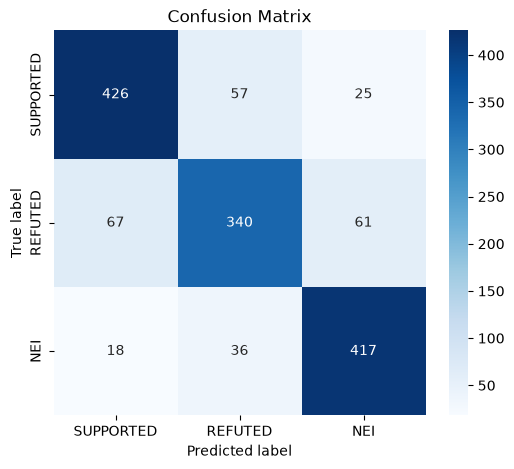

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = ["SUPPORTED", "REFUTED", "NEI"]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6.5, 5), dpi=150)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

plt.xlabel("Predicted Label (Nhãn dự đoán)", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("True Label (Nhãn thực tế)", fontsize=11, fontweight="bold", labelpad=10)
plt.title("BamiBERT Baseline - Confusion Matrix trên Tập Test", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## 11. Lưu Checkpoint Trọng số Mô hình & Tokenizer
Lưu lại toàn bộ weights của model tốt nhất cùng cấu hình tokenizer vào thư mục `./outputs/bamibert/best_model` để phục vụ inference độc lập hoặc triển khai tích hợp vào pipeline.

In [25]:
# Lưu model và tokenizer tốt nhất
OUTPUT_MODEL_DIR = "./outputs/bamibert/best_model"

trainer.save_model(OUTPUT_MODEL_DIR)
tokenizer.save_pretrained(OUTPUT_MODEL_DIR)

print(f"✓ Đã lưu thành công mô hình và tokenizer tại: {OUTPUT_MODEL_DIR}")

DONE


## 12. Module Kiểm thử Độc lập trên Câu Mới (Standalone Demo Inference)
Khối mã dưới đây được thiết kế **hoàn toàn độc lập (Self-contained)**:
- Tự nạp mô hình và tokenizer từ checkpoint `./outputs/bamibert/best_model` đã lưu ở trên (không phụ thuộc vào các biến toàn cục của quá trình train).
- Tự động nhận diện thiết bị phần cứng tối ưu (`MPS` trên Apple Silicon, `CUDA` trên GPU hoặc `CPU`).
- Cung cấp hàm `verify_fact(claim, evidence)` tiện lợi kèm biểu đồ phân phối xác suất Softmax.
- Thử nghiệm trên các câu tuyên bố mới hoàn toàn để kiểm tra khả năng suy luận logic và dữ kiện thời gian.

In [1]:
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Tự động xác định đường dẫn checkpoint best_model (hỗ trợ cả chạy từ root hoặc thư mục con)
possible_paths = [
    Path("./outputs/bamibert/best_model"),
    Path("../../../outputs/bamibert/best_model"),
    Path("../../outputs/bamibert/best_model"),
]
MODEL_PATH = next((p for p in possible_paths if p.exists()), Path("./outputs/bamibert/best_model"))

print(f"Đang nạp checkpoint từ: {MODEL_PATH}")
inf_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
inf_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
inf_model.eval()

# 2. Tự động nhận diện thiết bị tính toán (MPS trên Apple Silicon, CUDA hoặc CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
inf_model.to(device)
print(f"Thiết bị đang sử dụng: {device.type.upper()}")

# 3. Hàm kiểm chứng fact tổng quát kèm phân tích xác suất
def verify_fact(claim: str, evidence: str, title: str = ""):
    inputs = inf_tokenizer(
        claim,
        evidence,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inf_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0].cpu()
        pred_id = torch.argmax(outputs.logits, dim=1).item()
    
    pred_label = inf_model.config.id2label[pred_id]
    
    print("=" * 80)
    if title:
        print(f"📌 {title}")
        print("-" * 80)
    print(f"• TUYÊN BỐ (CLAIM):  {claim}")
    print(f"• BẰNG CHỨNG (EVID): {evidence}")
    print("-" * 80)
    print(f"👉 DỰ ĐOÁN:           {pred_label} (Xác suất: {probs[pred_id].item()*100:.2f}%)")
    print(f"Phân phối xác suất:")
    for idx in range(len(probs)):
        name = inf_model.config.id2label[idx]
        bar = "█" * int(probs[idx].item() * 25)
        print(f"  • {name:<12}: {probs[idx].item()*100:>6.2f}% | {bar}")
    print("=" * 80)
    print()

# 4. Thử nghiệm thực tế trên các tình huống kiểm chứng:

# Tình huống 1: Mâu thuẫn thời gian (Tuyên bố ghi năm 1950, Bằng chứng ghi tháng 4.1936) -> Kỳ vọng: REFUTED
verify_fact(
    claim="Vua hề Charlie Chaplin và vợ đã đến nghỉ trăng mật tại khách sạn Saigon Morin vào năm 1950.",
    evidence="Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin vào tháng 4.1936 tại phòng Charlie Chaplin Suite.",
    title="TÌNH HUỐNG 1: MÂU THUẪN DỮ KIỆN THỜI GIAN (1950 vs 1936)"
)

# Tình huống 2: Khẳng định đúng sự thật (Đúng thời gian tháng 4.1936 và nhân vật) -> Kỳ vọng: SUPPORTED
verify_fact(
    claim="Vào tháng 4.1936, Vua hề Charlie Chaplin và vợ đã có kỳ nghỉ trăng mật tại khách sạn Saigon Morin.",
    evidence="Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin vào tháng 4.1936 tại phòng Charlie Chaplin Suite.",
    title="TÌNH HUỐNG 2: XÁC THỰC THÔNG TIN ĐÚNG SỰ THẬT"
)

Đang nạp checkpoint từ: ./outputs/bamibert/best_model
Thiết bị đang sử dụng: MPS
📌 TÌNH HUỐNG 1: MÂU THUẪN DỮ KIỆN THỜI GIAN (1950 vs 1936)
--------------------------------------------------------------------------------
• TUYÊN BỐ (CLAIM):  Vua hề Charlie Chaplin và vợ đã đến nghỉ trăng mật tại khách sạn Saigon Morin vào năm 1950.
• BẰNG CHỨNG (EVID): Vua hề Charlie Chaplin (vua hề Sác lô) và vợ từng trải qua kỳ nghỉ trăng mật tại khách sạn Saigon Morin vào tháng 4.1936 tại phòng Charlie Chaplin Suite.
--------------------------------------------------------------------------------
👉 DỰ ĐOÁN:           REFUTED (Xác suất: 99.11%)
Phân phối xác suất:
  • SUPPORTED   :   0.36% | 
  • REFUTED     :  99.11% | ████████████████████████
  • NEI         :   0.53% | 

📌 TÌNH HUỐNG 2: XÁC THỰC THÔNG TIN ĐÚNG SỰ THẬT
--------------------------------------------------------------------------------
• TUYÊN BỐ (CLAIM):  Vào tháng 4.1936, Vua hề Charlie Chaplin và vợ đã có kỳ nghỉ trăng mật tại khách

## 13. Tài liệu Tham khảo & Trích dẫn Bài báo Gốc (Paper References)

Nghiên cứu và triển khai mô hình BamiBERT trong đồ án được tham chiếu từ công trình khoa học chính thức:

> **"BamiBERT: A New BERT-based Language Model for Vietnamese"**  
> *Tác giả:* Dat Quoc Nguyen, Thinh Pham, Chi Tran, Linh The Nguyen  
> *Đơn vị:* Qualcomm AI Research & Virginia Tech (arXiv:2607.02259v1, 2026)  
> *Kho lưu trữ & Trọng số công bố:* [HuggingFace - Qualcomm-AI-Research/BamiBERT](https://huggingface.co/Qualcomm-AI-Research/BamiBERT)  
> *(Ghi chú từ bài báo: "Bami" xuất phát từ "bánh mì" - món ăn quen thuộc mang tính biểu tượng văn hóa ẩm thực Việt Nam).*

### Các công trình liên quan:
1. **ViNLI Benchmark:** Tin Van Huynh, Kiet Van Nguyen, and Ngan Luu-Thuy Nguyen. 2022. *ViNLI: A Vietnamese Corpus for Studies on Open-Domain Natural Language Inference*. In Proceedings of COLING.
2. **RoBERTa Approach:** Yinhan Liu, Myle Ott, Naman Goyal, et al. 2019. *RoBERTa: A Robustly Optimized BERT Pretraining Approach*. arXiv:1907.11692.
3. **PhoGPT Tokenizer:** Dat Quoc Nguyen, Linh The Nguyen, Chi Tran, Dung Ngoc Nguyen, Dinh Phung, and Hung Bui. 2023. *PhoGPT: Generative Pre-training for Vietnamese*. arXiv:2311.02945.
4. **Hugging Face Transformers:** Thomas Wolf, Lysandre Debut, Victor Sanh, et al. 2020. *Transformers: State-of-the-Art Natural Language Processing*. In Proceedings of EMNLP.